In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
# IPL ball-by-ball deliveries dataset
# Dataset: deliveries.csv
from pandas import read_csv
df = read_csv("deliveries.csv")
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['match_id', 'inning', 'over', 'ball', 'batsman_runs', 'extra_runs', 'total_runs', 'is_wicket']
Categorical Features: ['batting_team', 'bowling_team', 'batter', 'bowler', 'non_striker', 'extras_type', 'player_dismissed', 'dismissal_kind', 'fielder']


/tmp/ipykernel_480/1869842994.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


In [5]:
# Select the core numerical columns for correlation analysis
numerical_cols = ['over', 'ball', 'batsman_runs', 'extra_runs', 'total_runs', 'is_wicket']
corr_matrix = df[numerical_cols].corr()

In [6]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                  over      ball  batsman_runs  extra_runs  total_runs  \
over          1.000000 -0.001241      0.080040    0.004437    0.081610   
ball         -0.001241  1.000000      0.004391    0.000176    0.004463   
batsman_runs  0.080040  0.004391      1.000000   -0.142079    0.977934   
extra_runs    0.004437  0.000176     -0.142079    1.000000    0.067852   
total_runs    0.081610  0.004463      0.977934    0.067852    1.000000   
is_wicket     0.072963  0.004258     -0.171751   -0.041903   -0.181955   

              is_wicket  
over           0.072963  
ball           0.004258  
batsman_runs  -0.171751  
extra_runs    -0.041903  
total_runs    -0.181955  
is_wicket      1.000000  


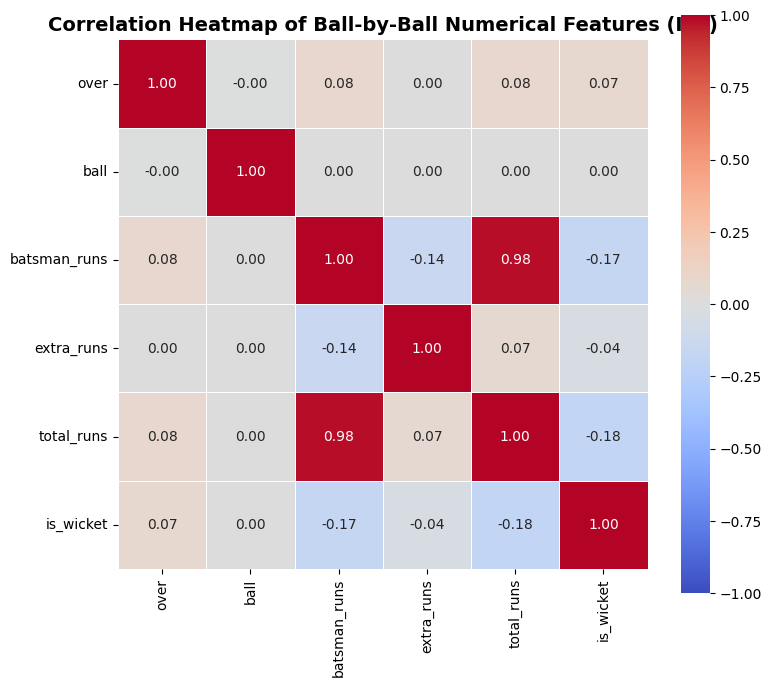

In [7]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(8,7))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Ball-by-Ball Numerical Features (IPL)", fontsize=14, fontweight="bold")
plt.tight_layout()

In [8]:
# Export Heatmap
import os
output_dir = "."
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: ./correlation_heatmap.png


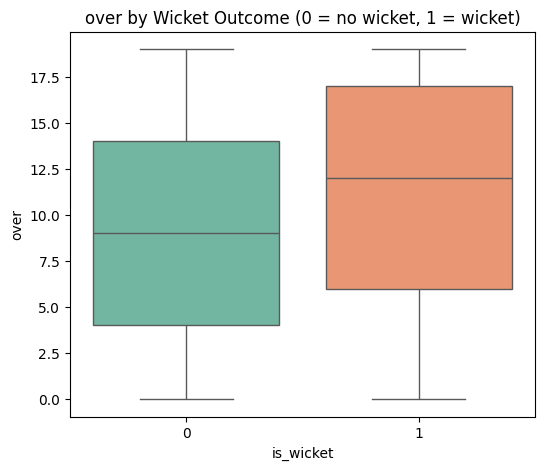

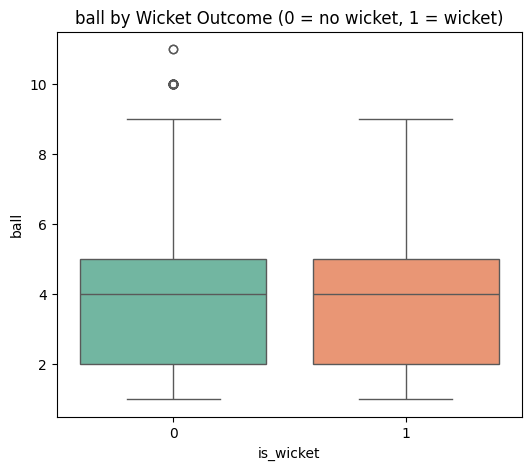

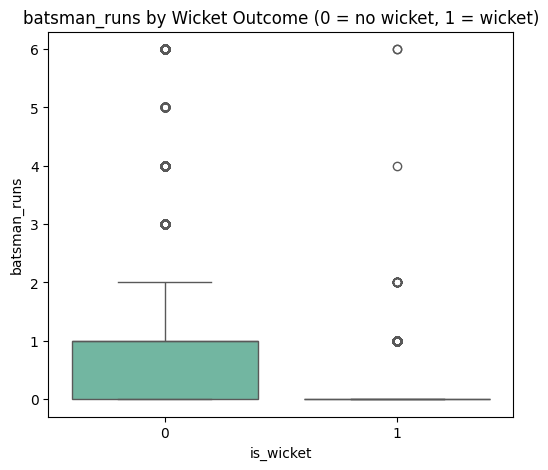

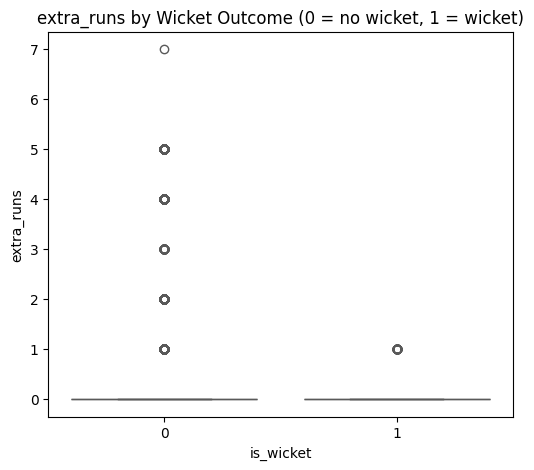

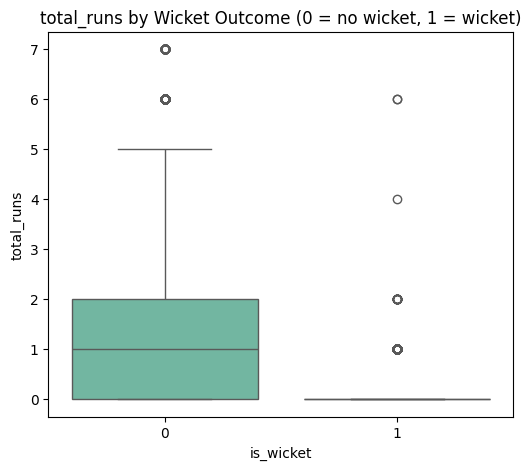

In [9]:
# -------------------------------------------------------------
# 3. Produce Boxplots: Numerical Features vs Wicket Outcome (is_wicket)
# -------------------------------------------------------------
target_col = "is_wicket"
box_cols = [c for c in numerical_cols if c != target_col]
if target_col in df.columns:
    for col in box_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} by Wicket Outcome (0 = no wicket, 1 = wicket)")
        plt.show()

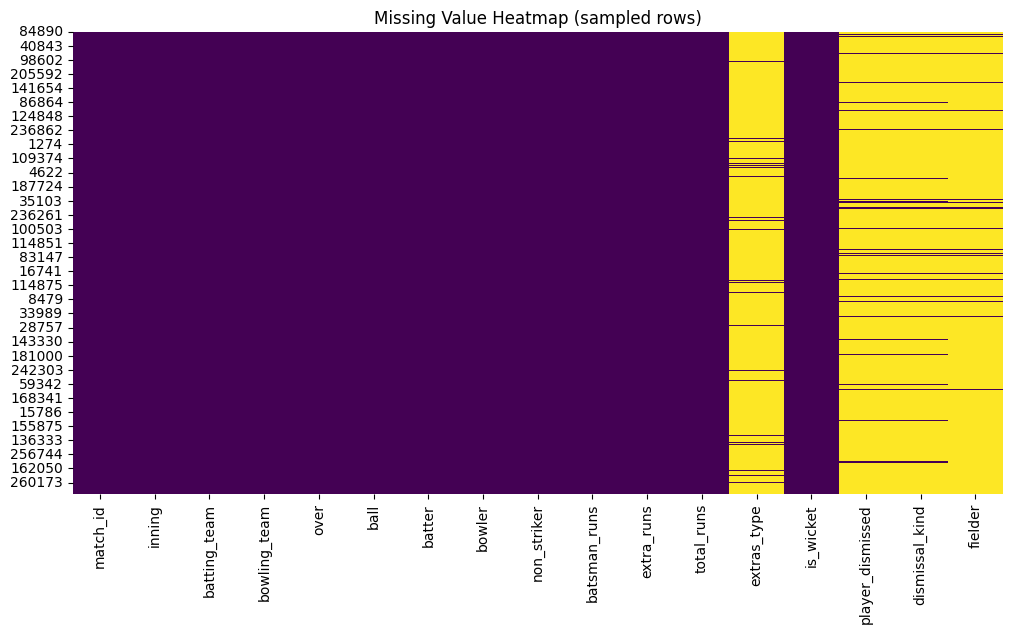

In [10]:
import matplotlib.pyplot as plt
fig1 = plt.figure(figsize=(12,6))

# Sample rows for a readable missing-value heatmap on this large dataset
sns.heatmap(
         df.sample(2000, random_state=42).isnull(),
        cbar=False,
         cmap="viridis"
)

plt.title("Missing Value Heatmap (sampled rows)")

plt.show()

### **Observation**

Unlike the earlier dataset, this ball-by-ball dataset does contain missing values, but they are structural rather than data-quality issues:

- `extras_type` is only populated when `extra_runs` were conceded on that ball (e.g. wide, no-ball, bye), so it is blank for the majority of deliveries.
- `player_dismissed`, `dismissal_kind`, and `fielder` are only populated when `is_wicket` = 1, so they are blank for every ball that did not result in a wicket.

Therefore, no imputation is needed — these missing values simply indicate "not applicable" rather than missing data.

<Figure size 1500x800 with 0 Axes>

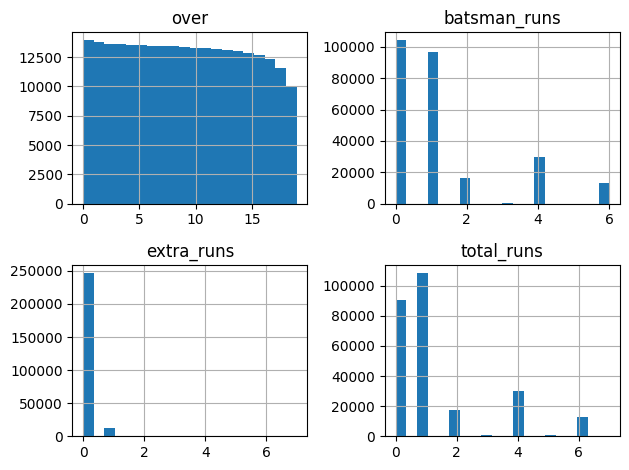

In [11]:
features = ["over", "batsman_runs", "extra_runs", "total_runs"]

fig2 = plt.figure(figsize=(15,8))
df[features].hist(
    bins=20
)

plt.tight_layout()

plt.show()

#Observations:
### **1. Overs**

Observation:

- Deliveries are roughly evenly spread across overs 0-19, as expected for a fixed 20-over innings format.

### **2. Runs per Ball (batsman_runs / total_runs)**

Observation:

- The vast majority of deliveries result in 0 or 1 run, with boundaries (4s and 6s) forming smaller, distinct spikes.
- The distribution is heavily right-skewed, which is typical for cricket scoring patterns.
- `extra_runs` is almost always 0, with a small number of deliveries conceding 1 or more extras (wides, no-balls, byes, leg-byes).

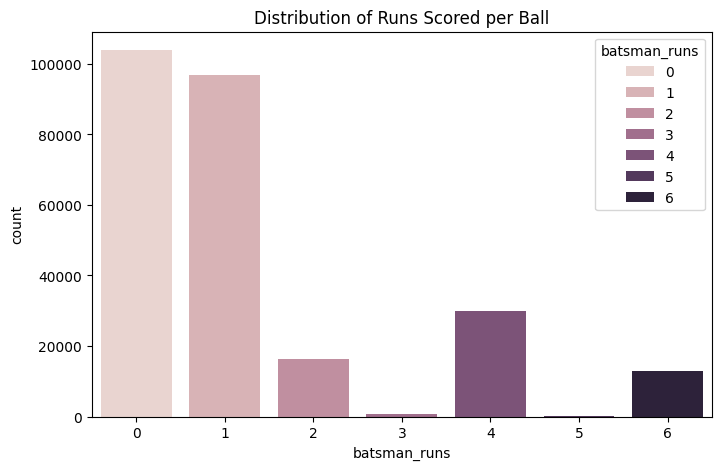

In [12]:
# Distribution of runs scored off the bat per ball

fig3 = plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="batsman_runs",
    hue="batsman_runs"
)

plt.title("Distribution of Runs Scored per Ball")

plt.show()

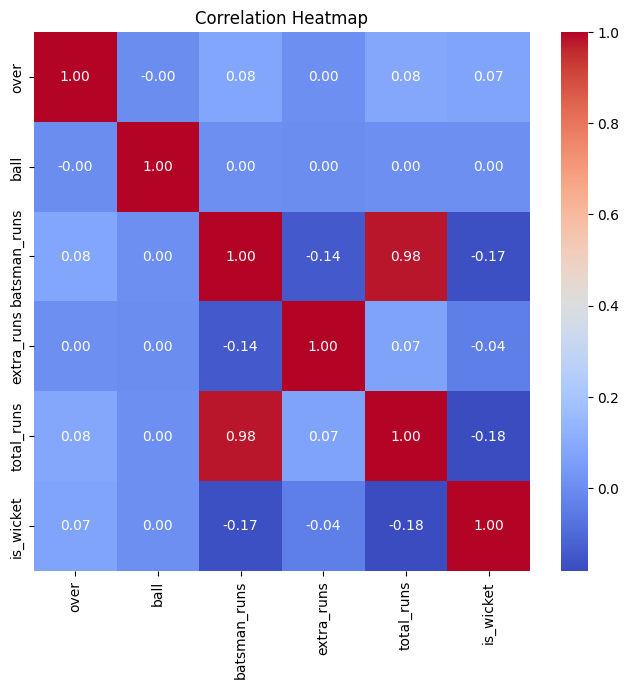

In [13]:
#Correlation Heatmap

fig5 = plt.figure(figsize=(8,7))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Correlation Heatmap

To identify the relationship among numerical features and understand which variables are positively or negatively correlated before model development.
A correlation heatmap visualizes the Pearson correlation coefficient between numerical features.

The correlation coefficient (r) ranges from **-1 to +1**.

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

Generally,

- **0.70 to 1.00** → Strong positive correlation
- **0.40 to 0.69** → Moderate positive correlation
- **0.00 to 0.39** → Weak positive correlation
- **-0.40 to -0.69** → Moderate negative correlation
- **-0.70 to -1.00** → Strong negative correlation

##Example:

# **1. Coding Skills vs Certifications = 0.86**
Observation
-A strong positive relationship exists.
-Students with better coding skills usually earn more certifications.
-Certifications appear to reflect technical competency.


# 2. Student_ID, Correlation ≈ 0
Observation

- It has no relationship with placement or academic performance.
- It should be removed before model training.

#3.CGPA vs Backlogs = -0.58
    -As CGPA increases, the number of backlogs generally decreases.

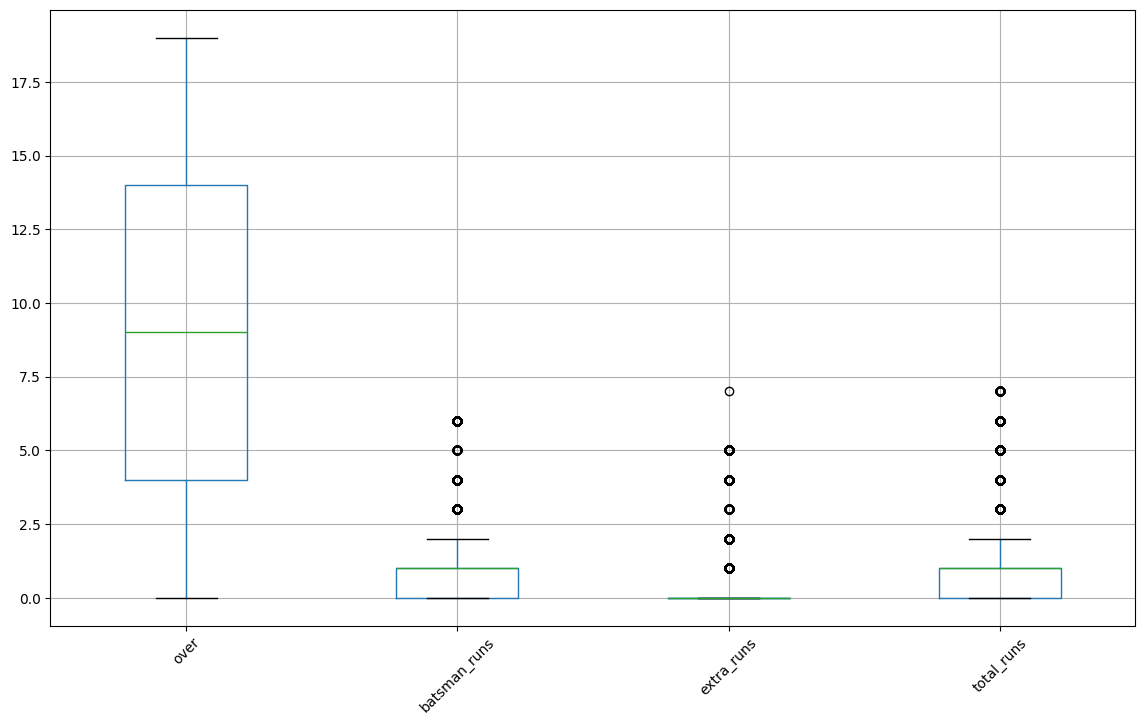

In [14]:
#boxplots
numerical_columns = [
    "over",
    "batsman_runs",
    "extra_runs",
    "total_runs"
]


fig6 = plt.figure(figsize=(14,8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.show()

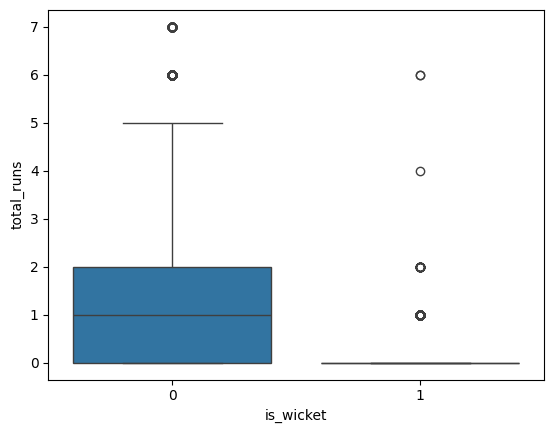

In [15]:
fig7 = sns.boxplot(x='is_wicket', y='total_runs', data=df)

In [16]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig5)
    pdf.savefig(fig6)


print("EDA Report saved successfully.")

EDA Report saved successfully.
